## Задание 


1. Выберите любой ряд для анализа (из материалов к заданию или с kaggle/работы, тп).
2. Проведите анализ ряда с помощью SSA разными длинами окон: необходимо взять как минимум 3 разных окна.
3. Постройте матрицы W-корреляций для каждого размера окна.
4. Сравните результаты и сделайте выводы, как размер окна влияет на качество приближения. Какой бы размер окна вы использовали для выбранного ряда?

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



import warnings
warnings.filterwarnings("ignore")


## Подготовка данных и функций

In [2]:
airlines_passengers = pd.read_csv("/Users/sofagusina/Desktop/код/machine_learning/machine_learning/ML/Временные ряды/Сингулярный спектральный анализ/Материалы к занятию «Знакомство с временными рядами»/Series/international-airline-passengers.csv")

In [68]:
len(airlines_passengers['Count'])

144

In [3]:
def plot_(model,series,title):
    with plt.style.context('bmh'):
        plt.figure(figsize=(8, 8))
        if model == None:
            plt.plot(series, color='blue', linewidth='2', label='Real')
        else:
            plt.plot(model, color='red', linewidth='2', label='Pred')
            plt.plot(series, color='blue', linewidth='2', label='Real')
        plt.legend()
        plt.title(f'{title}')

    plt.show()

### Класс для SSA 

In [101]:
class SSA_method (object):
    __supported_types = (pd.Series, np.ndarray, list)

    def __init__(self,series, L, save_mem = True):

        if not isinstance (series,self.__supported_types):
            raise TypeError('Некорректный тип исходных данных. Нужно использовать дата-серию, массив numpy или массив python')
        
        self.N = len (series)

        if not 2<=L<= self.N/2:
            raise ValueError ('Некорректный размер окна. Нужно выбрать окно в диапазоне [2,len(series)/2]')
        
        ## подготовка данных
        self.L = L
        self.series = pd.Series(series)
        self.K = self.N - self.L + 1 ## число столбцов в траекторной матрице (размер серии - размер окна + 1)

        self.X = np.array([self.series.values[i:L+i] for i in range (0,self.K)]).T ## сначала создаем вектора значений, проходясь окном по всем значениям серии, от 0 до заданного K, затем переводим в матрицу и транспонируем
        ## self.series.values[i:L+i]  - создает массив среда от i до i+L невключительно

        ## разкладываем матрицу на три по теореме SVD
        self.U, self.sigma, self.V = np.linalg.svd(self.X) ## матриц разделяется на 3 компоненты согласно линейной алгебре при решении уравнений (для сигмы) и при построении собственных векторов матриц V и U
        self.d = np.linalg.matrix_rank(self.X) ## ранг матрицы
        self.TS_component = np.zeros((self.N,self.d)) ## задаем нулевую матрицу компонентов размером N х rang
        
        """
        1. Выделяем компоненты, выявляя таким образом детермированный сингал (тренд, шум, сезонность)
        2. Восстаналиваем исходный ряд

        """
        if save_mem: ##  сохраняем матрицы компонентов - ее размер столбцов равен рангу исходной матрицы, количество компонентов - число детерменированных сигналов
            self.X_elem = np.array([self.sigma[i]*np.outer(self.U[:,i],self.V[i,:]) for i in range(self.d)]) ## np.outer(self.U[:,i],self.V[i,:]) - произведение матриц столбец матрицы U на строку матрицы V
            
            for i in range (self.d):
                X_rev = self.X_elem[i,::-1] ## выделяем один компонент в обратном порядке (4 строка в компоненте становится 1)
                self.TS_component[:,i] = [X_rev.diagonal(j).mean() for j in range(-X_rev.shape[0]+1,X_rev.shape[1])] ## проходимся по всем диагоналяем и усредняем значения на них
                self.V = self.V.T ## обратно транспонируем вектор

        else: ## не сохраняем

            self.X_elem = "Перезапустите с save_mem=True, чтобы сохранить элементарные матрицы"
            self.V = "Перезапустите с save_mem=True, чтобы сохранить матрицу V"

        """Рассчитываем матрицу корреляций"""
        self.calc_corr()
    
    def components_to_df (self,n=0):
        """Возвращает заданное количество компонент в формате дата-фрейма"""

        if n > 0:
            n = min(n,self.d) ## если n будет превышать число компонент в матрице, то вернется максимальное количество компонент
        else:
            n = self.d ## аналогично вернется максимальное, если n будет = 0 или отрицательным (по ошибке)
        
        columns = ['F{}'.format(i) for i  in range(n)] ## создаем столбцы по количеству компонент
        return pd.DataFrame(self.TS_component[:,:n],columns=columns,index = self.series.index)
    
    def reconstruct_ts(self,index):
        """Реконструирует временной ряд по заданным компонентам"""
        if isinstance(index, int):  
            index = [index]  # превращаем в список для единообразия

        elif isinstance(index, slice):
            index = list(range(self.d))[index]  # превращаем slice в список индексов
        elif not isinstance(index, (list, tuple, np.ndarray)):
            raise TypeError("index должен быть int, list, tuple или slice")
    
        ts_val = self.TS_component[:,index].sum(axis=1) ## получаем элементы ряда внутри заданной компоненты
        return pd.DataFrame(ts_val,index = self.series.index)

    def calc_corr(self):
        """Рассчитываем матрицу корреляций компонентов для временного ряда"""
        w = np.array(list(np.arange(self.L)+1)+[self.L]*(self.K-self.L - 1)+list(np.arange(self.L) + 1)[::-1] ) ## list(np.arange(self.L) + 1)[::-1] - генериуем массив чисел, которые возрастают от 1 до L+1 и переворачиваем его в другую сторону

        def corr_comp (F_i,F_j):
            """Рассчитаем векторное произведение двух реконструированных временных рядов"""
            return np.dot(w, F_i * F_j)
        

        F_wnorms = np.array([corr_comp(self.TS_component[:,i],self.TS_component[:,i]) for i in range (self.d)]) ## вычисляем индивидуальные взвешенные нормы компонента
        F_wnorms = F_wnorms ** -0.5

        self.W_corr = np.identity(self.d) ## создаем диагональную матрицу

        for i in range(self.d): ## для каждого разбитого временного ряда согласно компонентам вычисляем корреляцию
            for j in range (i+1,self.d):
                self.W_corr[i,j] = abs(corr_comp(self.TS_component[:,i],self.TS_component[:,j])*F_wnorms[i]*F_wnorms[j])
                self.W_corr[i,j] = self.W_corr[i,j]
    
    def plot_wcorr(self,min = None, max = None):

        """Построение матрицы корреляции"""

        ### создаем границы таблицы
        if min is None:
            min = 0
        
        if max is None:
            max = self.d

        if self.W_corr is None:
            self.calc_corr
        
        ax = plt.imshow(self.W_corr)

        plt.xlabel(r"$\tilde{F}_i$")
        plt.ylabel(r"$\tilde{F}_j$")
        plt.colorbar(ax.colorbar, fraction=0.045)
        ax.colorbar.set_label("$W_{i,j}$")
        plt.clim(0,1)
    
		# Для построения графика:
        if max == self.d:
            max_rnge = self.d-1
        else:
            max_rnge = max
        
        plt.xlim(min-0.5, max_rnge+0.5)
        plt.ylim(max_rnge+0.5, min-0.5)

    

## Реализация

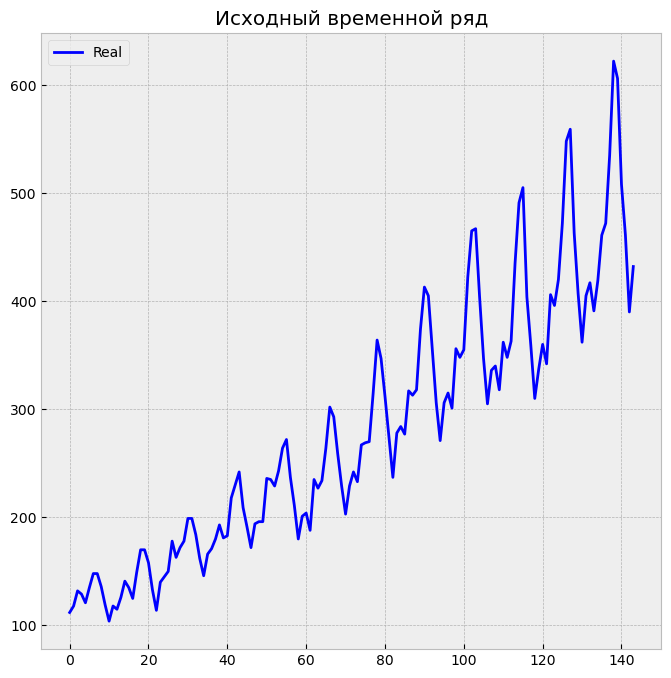

In [108]:
plot_(series=airlines_passengers['Count'],model=None,title='Исходный временной ряд')

У исходного временного ряда наблюдается сезонность и ярко выраженный тренд. За сезонность должна отвечать компонента синусоиды с изменяющейся амплитудой

### Разложение временного ряда на компоненты при длине окна L = 10

Text(0.5, 1.0, '$L=10$ for the Airlines Passangers')

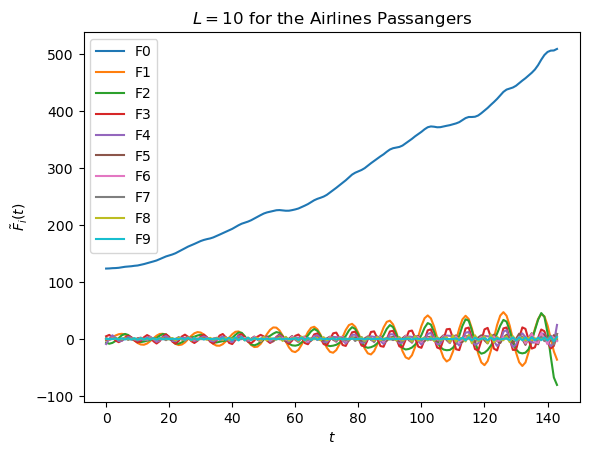

In [167]:
F_ssa_L10 = SSA_method(series=airlines_passengers['Count'], L=10)
F_ssa_L10.components_to_df().plot()
plt.xlabel("$t$")
plt.ylabel(r"$\tilde{F}_i(t)$")
plt.title(r"$L=10$ for the Airlines Passangers")


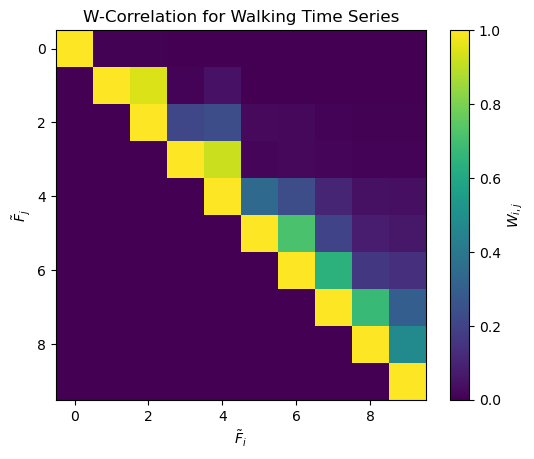

In [88]:
F_ssa_L10.plot_wcorr()
plt.title("W-Correlation for Walking Time Series");

На матрице корреляций видно, что шум начинается уже с первого компонента (он скоррелирован с шумовым компонентом), между собой хорошо скореллированы компоненты 4 и 5, 3 и 4, 6 и 7, 7 и 8, 8 и 9, 5 и 6. Самую высокую корреляцию имеют компоненты 1 и 2, 3 и 4, что также видно на графике разложенного временного ряда. Посмотрим представление ряда в группе компонент. Первая группа 1-4(сезонность), вторая группа F5-F9 (шум) и единственный элемент F0 (тренд)

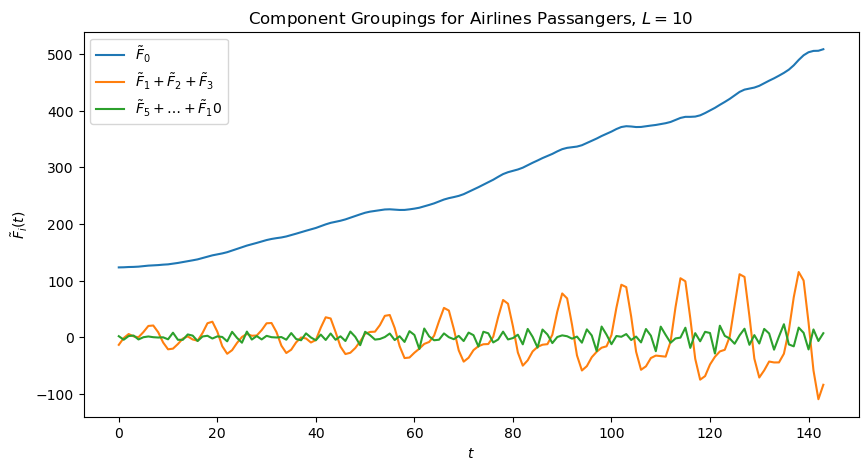

In [168]:
fig, ax = plt.subplots(figsize=(10,5))

F_ssa_L10.reconstruct_ts(0).plot(ax=ax)
F_ssa_L10.reconstruct_ts([1,2,3,4]).plot(ax=ax)
F_ssa_L10.reconstruct_ts(slice(5,10)).plot(ax=ax)

ax.set_xlabel("$t$")
ax.set_ylabel(r"$\tilde{F}_i(t)$")
ax.set_title("Component Groupings for Airlines Passangers, $L=10$")
ax.legend([r"$\tilde{F}_0$", 
           r"$\tilde{F}_1+\tilde{F}_2+\tilde{F}_3$", 
           r"$\tilde{F}_5+ \ldots + \tilde{F}_10$"])

На графике явно видно 3 компоненты - тренд, сезонность и шум

### Разложение временного ряда при длине окна 40

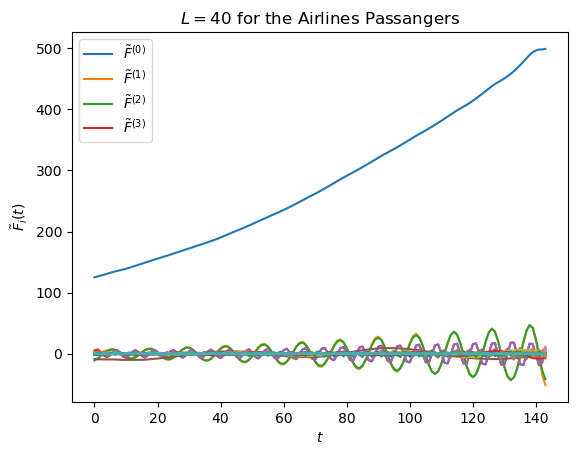

In [169]:
F_ssa_L40 = SSA_method(series=airlines_passengers['Count'], L=40)
F_ssa_L40.components_to_df().plot()
plt.xlabel("$t$")
plt.ylabel(r"$\tilde{F}_i(t)$")
plt.title(r"$L=40$ for the Airlines Passangers")
plt.legend([r"$\tilde{{F}}^{{({0})}}$".format(i) for i in range(4)])

Компоненты ряда сильно накладываются друг на друга, поэтому невозможно однозначно определить группы компонент. Для этого посмотрим матрицу корреляций

Text(0.5, 1.0, 'W-Correlation for Walking Time Series')

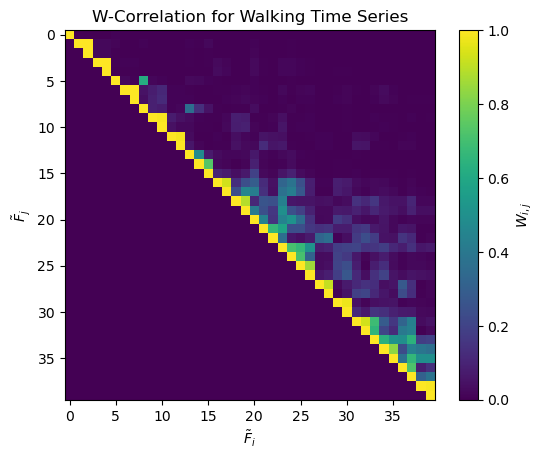

In [170]:
F_ssa_L40.plot_wcorr()
plt.title("W-Correlation for Walking Time Series")

По матрице корреляций видно, что шум начинается примерно с первого компонента (что было видно и на матрице корреляций при окне размером 10). Много шумовых данных появляется после 8-10 компонентов. Выведем компоненты с 0 по 10 на укрупненную матрицу корреляций

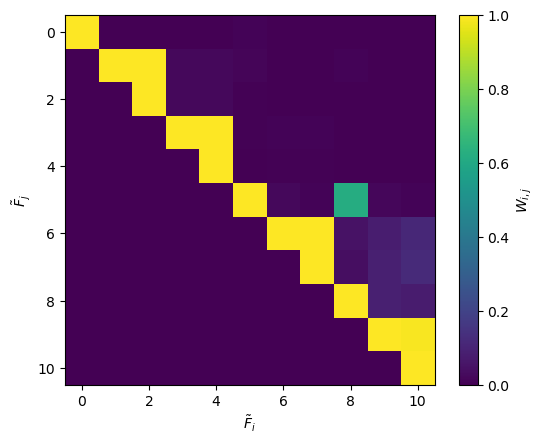

In [112]:
F_ssa_L40.plot_wcorr(max=10)

На данной матрице лучше видно, что компоненты 1 и 2, 3 и 4, 6 и 7, 9 и 10 очень высоко скореллированы между собой. Посмотрим график групп компонент временного ряда

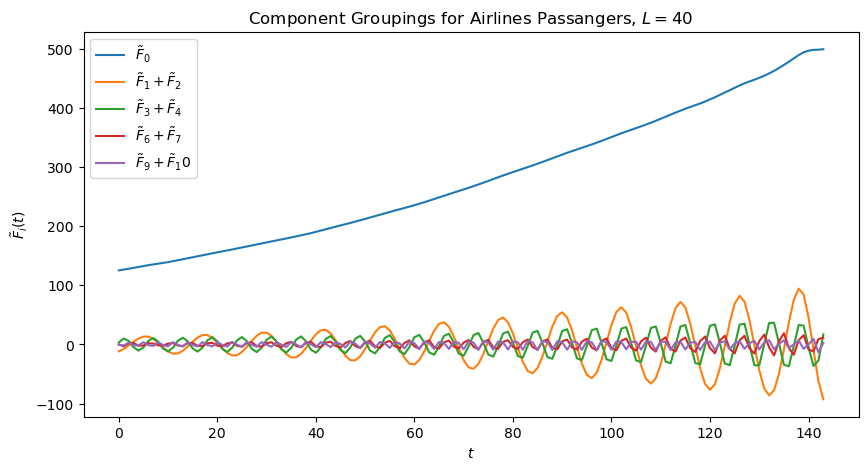

In [171]:
fig, ax = plt.subplots(figsize=(10,5))

F_ssa_L40.reconstruct_ts(0).plot(ax=ax)
F_ssa_L40.reconstruct_ts([1,2]).plot(ax=ax)
F_ssa_L40.reconstruct_ts([3,4]).plot(ax=ax)
F_ssa_L40.reconstruct_ts([6,7]).plot(ax=ax)
F_ssa_L40.reconstruct_ts([9,10]).plot(ax=ax)


ax.set_xlabel("$t$")
ax.set_ylabel(r"$\tilde{F}_i(t)$")
ax.set_title("Component Groupings for Airlines Passangers, $L=40$")
ax.legend([r"$\tilde{F}_0$", 
           r"$\tilde{F}_1+\tilde{F}_2$", 
           r"$\tilde{F}_3+\tilde{F}_4$",
           r"$\tilde{F}_6+\tilde{F}_7$",
           r"$\tilde{F}_9+\tilde{F}_10$",])

По данному графику отлично видно, что f1+f2 и f3+f4 - сезонность, f0- тренд, все остальные компоненты - шум. Посмотрим график, если объеднить f1+f2 и f3+f4 

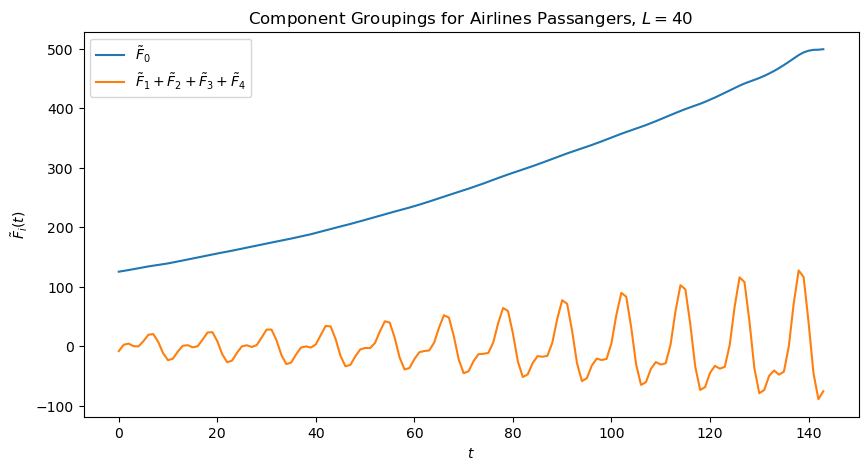

In [172]:
fig, ax = plt.subplots(figsize=(10,5))

F_ssa_L40.reconstruct_ts(0).plot(ax=ax)
F_ssa_L40.reconstruct_ts([1,2,3,4]).plot(ax=ax)



ax.set_xlabel("$t$")
ax.set_ylabel(r"$\tilde{F}_i(t)$")
ax.set_title("Component Groupings for Airlines Passangers, $L=40$")
ax.legend([r"$\tilde{F}_0$", 
           r"$\tilde{F}_1+\tilde{F}_2 + \tilde{F}_3+\tilde{F}_4$",])

Данное разложение ряда с окном 40 демонстрирует хорошее качество, немного лучше, чем разложение с окном 10, так как более точно разделяет компоненты, что позволяет при их группировке добиться более качественного разложения ряда на составляющие

### Разложение ряда с окном N/2=72

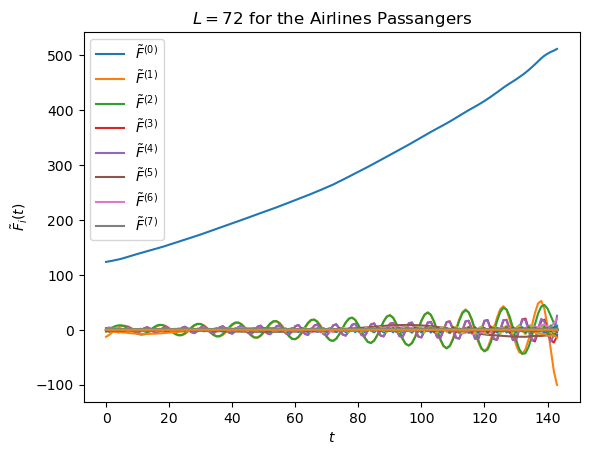

In [173]:
F_ssa_L72 = SSA_method(series=airlines_passengers['Count'], L=72)
F_ssa_L72.components_to_df().plot()
plt.xlabel("$t$")
plt.ylabel(r"$\tilde{F}_i(t)$")
plt.title(r"$L=72$ for the Airlines Passangers")
plt.legend([r"$\tilde{{F}}^{{({0})}}$".format(i) for i in range(8)])

Наблюдается много компонент, характеризующих шумовые данные. Посмотрим матрицу корреляций

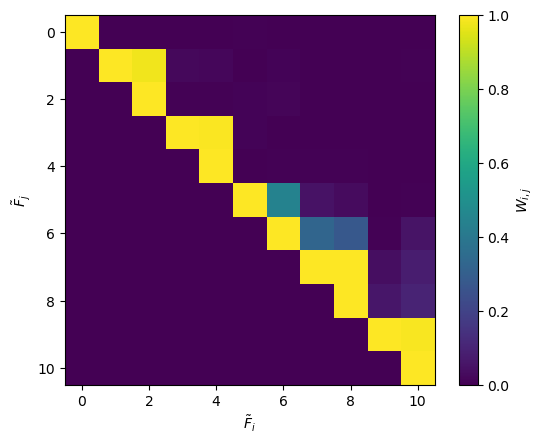

In [127]:
F_ssa_L72.plot_wcorr(max=10)

Также наблюдается корреляция компонент 1 и 2, 3 и 4, 9  и 10 и  не очень высокая 6 и 7. Выявлена новая высокая корреляция компонент 7 и 8, не очень высокая 5 и 6 

Посмотрим график вышеуказанных групп. Скорее всего, компоненты 5, 7 и 8 - шумовые, так как на матрице видно, что они имеют некоторую корреляцию с шумом

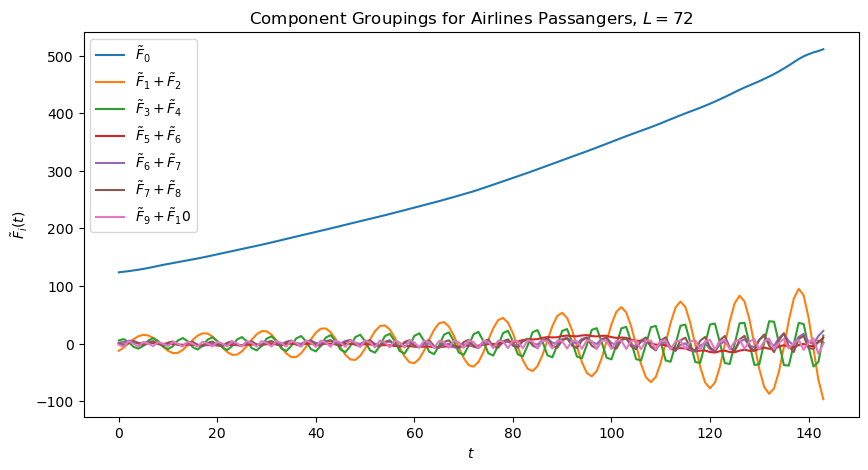

In [174]:
fig, ax = plt.subplots(figsize=(10,5))

F_ssa_L72.reconstruct_ts(0).plot(ax=ax)
F_ssa_L72.reconstruct_ts([1,2]).plot(ax=ax)
F_ssa_L72.reconstruct_ts([3,4]).plot(ax=ax)
F_ssa_L72.reconstruct_ts([5,6]).plot(ax=ax)
F_ssa_L72.reconstruct_ts([6,7]).plot(ax=ax)
F_ssa_L72.reconstruct_ts([7,8]).plot(ax=ax)
F_ssa_L72.reconstruct_ts([9,10]).plot(ax=ax)


ax.set_xlabel("$t$")
ax.set_ylabel(r"$\tilde{F}_i(t)$")
ax.set_title("Component Groupings for Airlines Passangers, $L=72$")
ax.legend([r"$\tilde{F}_0$", 
           r"$\tilde{F}_1+\tilde{F}_2$", 
           r"$\tilde{F}_3+\tilde{F}_4$",
           r"$\tilde{F}_5+\tilde{F}_6$",
           r"$\tilde{F}_6+\tilde{F}_7$",
           r"$\tilde{F}_7+\tilde{F}_8$",
           r"$\tilde{F}_9+\tilde{F}_10$",])

Так и есть: f5-f10 - шум. Сгруппируем f1-f4 и нанесем f1-f4 с результата разложения окном 40

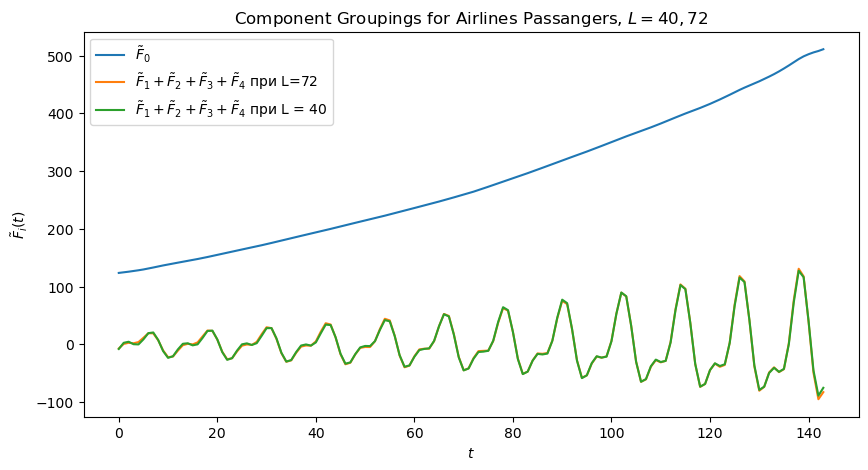

In [175]:
fig, ax = plt.subplots(figsize=(10,5))

F_ssa_L72.reconstruct_ts(0).plot(ax=ax)
F_ssa_L72.reconstruct_ts([1,2,3,4]).plot(ax=ax)
F_ssa_L40.reconstruct_ts([1,2,3,4]).plot(ax=ax)



ax.set_xlabel("$t$")
ax.set_ylabel(r"$\tilde{F}_i(t)$")
ax.set_title("Component Groupings for Airlines Passangers, $L=40,72$")
ax.legend([r"$\tilde{F}_0$", 
           r"$\tilde{F}_1+\tilde{F}_2 + \tilde{F}_3+\tilde{F}_4$ при L=72",
           r"$\tilde{F}_1+\tilde{F}_2 + \tilde{F}_3+\tilde{F}_4$ при L = 40"])

Обе группы компонентов практически идентично отображают сезонность, группа при окне 72 больше учитывает "углы". Посмотрим разницу в шумовых компонентах

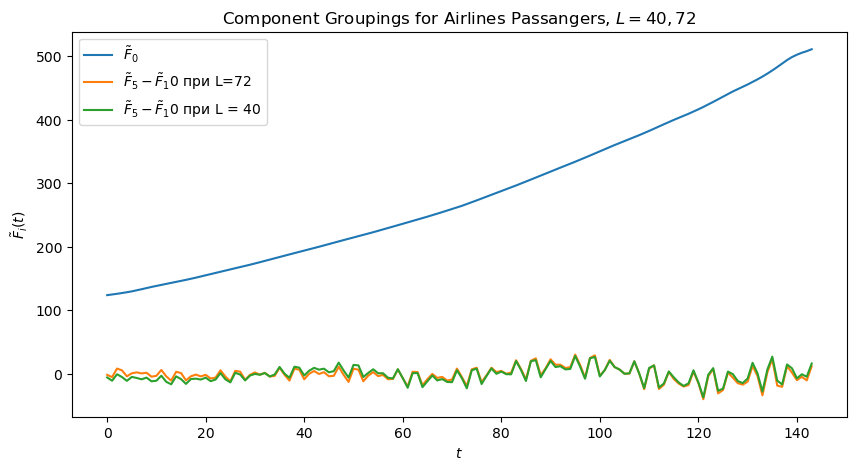

In [176]:
fig, ax = plt.subplots(figsize=(10,5))

F_ssa_L72.reconstruct_ts(0).plot(ax=ax)
F_ssa_L72.reconstruct_ts(slice(5,11)).plot(ax=ax)
F_ssa_L40.reconstruct_ts(slice(5,11)).plot(ax=ax)



ax.set_xlabel("$t$")
ax.set_ylabel(r"$\tilde{F}_i(t)$")
ax.set_title("Component Groupings for Airlines Passangers, $L=40,72$")
ax.legend([r"$\tilde{F}_0$", 
           r"$\tilde{F}_5 - \tilde{F}_10$ при L=72",
           r"$\tilde{F}_5 - \tilde{F}_10$ при L = 40"])

Есть несущественные отличия, теперь наложим сезонность + шум + тренд и посмотрим разницу

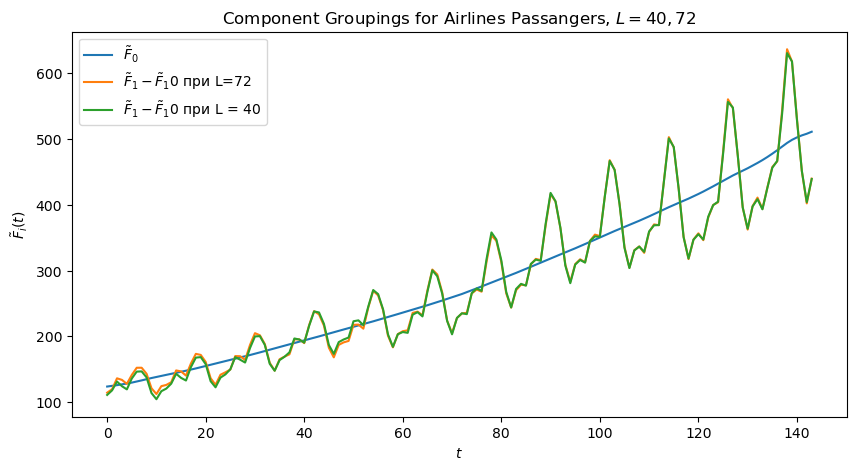

In [177]:
fig, ax = plt.subplots(figsize=(10,5))

F_ssa_L72.reconstruct_ts(0).plot(ax=ax)
F_ssa_L72.reconstruct_ts(slice(0,11)).plot(ax=ax)
F_ssa_L40.reconstruct_ts(slice(0,11)).plot(ax=ax)



ax.set_xlabel("$t$")
ax.set_ylabel(r"$\tilde{F}_i(t)$")
ax.set_title("Component Groupings for Airlines Passangers, $L=40,72$")
ax.legend([r"$\tilde{F}_0$", 
           r"$\tilde{F}_1 - \tilde{F}_10$ при L=72",
           r"$\tilde{F}_1 - \tilde{F}_10$ при L = 40"])

К концу ряда компоненты полностью накладываются друг на друга, исходя из чего можно сделать вывод: что при окне 40, что при окне 72 компоненты разложения практически не меняются

## Выводы о работе

Для корректного вывода отобразим на одном графике три разложения с тремя разными окнами 10,40 и 72 и посмотрим, как влияет размер окна на качество разложение ряда

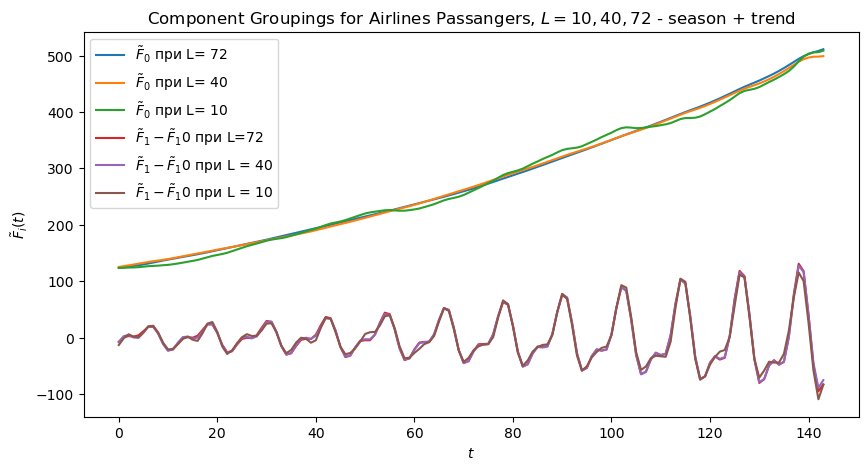

In [178]:
fig, ax = plt.subplots(figsize=(10,5))

F_ssa_L72.reconstruct_ts(0).plot(ax=ax)
F_ssa_L40.reconstruct_ts(0).plot(ax=ax)
F_ssa_L10.reconstruct_ts(0).plot(ax=ax)
F_ssa_L72.reconstruct_ts([1,2,3,4]).plot(ax=ax)
F_ssa_L40.reconstruct_ts([1,2,3,4]).plot(ax=ax)
F_ssa_L10.reconstruct_ts([1,2,3,4]).plot(ax=ax)



ax.set_xlabel("$t$")
ax.set_ylabel(r"$\tilde{F}_i(t)$")
ax.set_title("Component Groupings for Airlines Passangers, $L=10,40,72$ - season + trend")
ax.legend([r"$\tilde{F}_0$ при L= 72",
           r"$\tilde{F}_0$ при L= 40",
           r"$\tilde{F}_0$ при L= 10" ,
           r"$\tilde{F}_1 - \tilde{F}_10$ при L=72",
           r"$\tilde{F}_1 - \tilde{F}_10$ при L = 40",
           r"$\tilde{F}_1 - \tilde{F}_10$ при L = 10"])

При наложении двух компонент каждого из разложений видно, что они практически совпадают, различия несущественны, что демонстрирует теорию о том, что после размера окна 10 качество разложения не меняется - по факту 10 компонент способы хорошо описать ряд. 

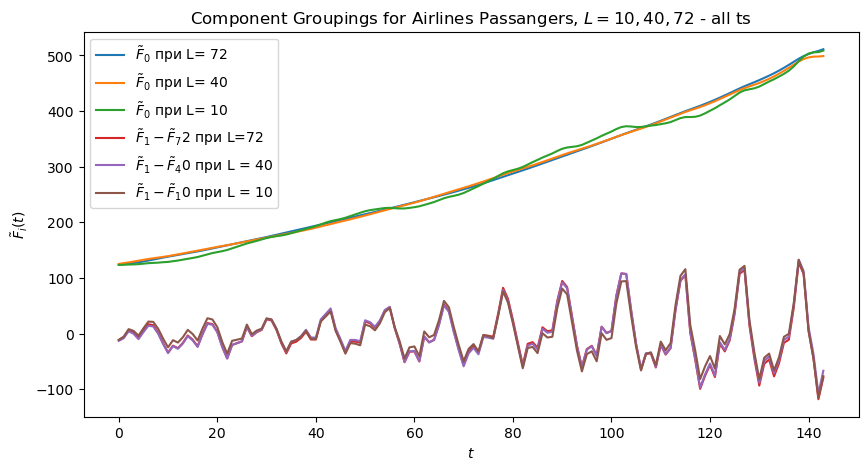

In [179]:
fig, ax = plt.subplots(figsize=(10,5))

F_ssa_L72.reconstruct_ts(0).plot(ax=ax)
F_ssa_L40.reconstruct_ts(0).plot(ax=ax)
F_ssa_L10.reconstruct_ts(0).plot(ax=ax)
F_ssa_L72.reconstruct_ts(slice(1,72)).plot(ax=ax)
F_ssa_L40.reconstruct_ts(slice(1,40)).plot(ax=ax)
F_ssa_L10.reconstruct_ts(slice(1,10)).plot(ax=ax)



ax.set_xlabel("$t$")
ax.set_ylabel(r"$\tilde{F}_i(t)$")
ax.set_title("Component Groupings for Airlines Passangers, $L=10,40,72$ - all ts")
ax.legend([r"$\tilde{F}_0$ при L= 72",
           r"$\tilde{F}_0$ при L= 40",
           r"$\tilde{F}_0$ при L= 10" ,
           r"$\tilde{F}_1 - \tilde{F}_72$ при L=72",
           r"$\tilde{F}_1 - \tilde{F}_40$ при L = 40",
           r"$\tilde{F}_1 - \tilde{F}_10$ при L = 10"])

При сложении всех компонент ряда видно, что разложения с окном 40 и 72 наиболее полно отображает шумовые данные по сравнению с разложением с окном 10. Сезонность отображается примерно одинаково, как и тренд. 

Посмотрим разложение с окном 3 для сравнения

Text(0.5, 1.0, '$L=3$ for the Airlines Passangers')

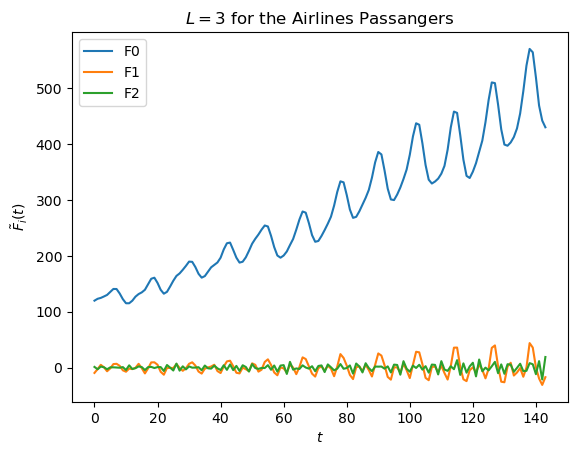

In [180]:
F_ssa_L3 = SSA_method(series=airlines_passengers['Count'], L=3)
F_ssa_L3.components_to_df().plot()
plt.xlabel("$t$")
plt.ylabel(r"$\tilde{F}_i(t)$")
plt.title(r"$L=3$ for the Airlines Passangers")


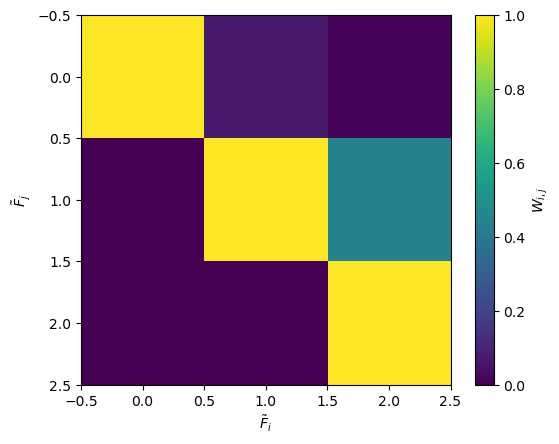

In [155]:
F_ssa_L3.plot_wcorr()

Тренд не выделяется, путается с сезонностью. Качество разложения низкое, что понятно: ряд раскладывается всего на 3 компоненты, которые невозможно сгруппировать и которые не отвечают за конкретный сигнал. Нанесем ряд на общий график

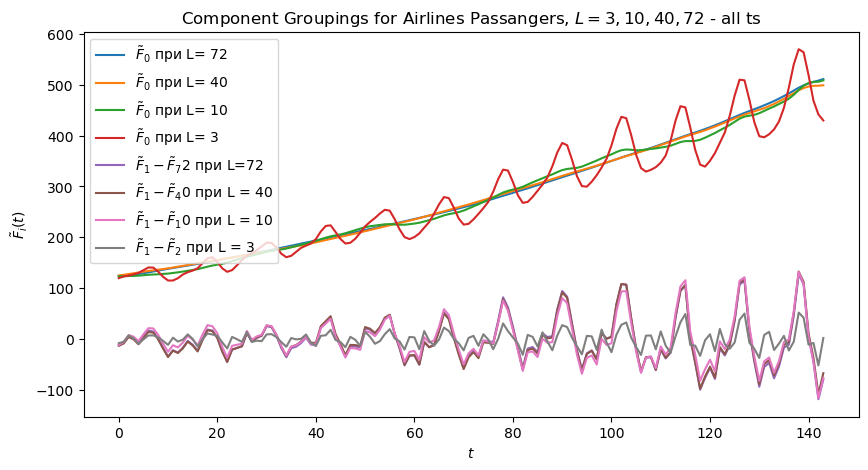

In [181]:
fig, ax = plt.subplots(figsize=(10,5))

F_ssa_L72.reconstruct_ts(0).plot(ax=ax)
F_ssa_L40.reconstruct_ts(0).plot(ax=ax)
F_ssa_L10.reconstruct_ts(0).plot(ax=ax)
F_ssa_L3.reconstruct_ts(0).plot(ax=ax)
F_ssa_L72.reconstruct_ts(slice(1,72)).plot(ax=ax)
F_ssa_L40.reconstruct_ts(slice(1,40)).plot(ax=ax)
F_ssa_L10.reconstruct_ts(slice(1,10)).plot(ax=ax)
F_ssa_L3.reconstruct_ts(slice(1,3)).plot(ax=ax)



ax.set_xlabel("$t$")
ax.set_ylabel(r"$\tilde{F}_i(t)$")
ax.set_title("Component Groupings for Airlines Passangers, $L=3,10,40,72$ - all ts")
ax.legend([r"$\tilde{F}_0$ при L= 72",
           r"$\tilde{F}_0$ при L= 40",
           r"$\tilde{F}_0$ при L= 10" ,
           r"$\tilde{F}_0$ при L= 3" ,
           r"$\tilde{F}_1 - \tilde{F}_72$ при L=72",
           r"$\tilde{F}_1 - \tilde{F}_40$ при L = 40",
           r"$\tilde{F}_1 - \tilde{F}_10$ при L = 10",
           r"$\tilde{F}_1 - \tilde{F}_2$ при L = 3"])

Отличие в разложении коллосальное. Посмотрим еще для примера окно размером 5, будет ли уменьшение в качестве разложения по сравнению с окнами 10,40 и 72

Text(0.5, 1.0, '$L=5$ for the Airlines Passangers')

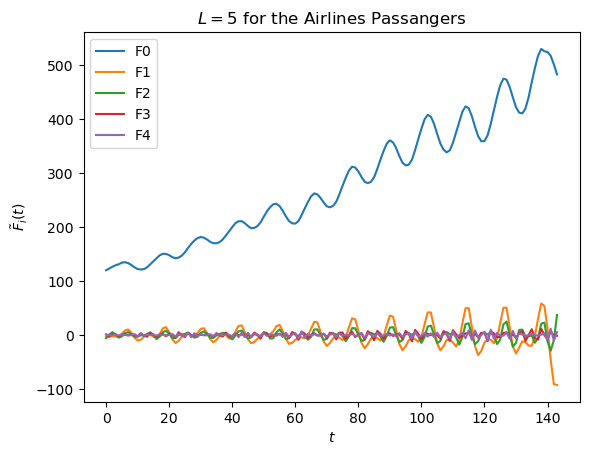

In [182]:
F_ssa_L5 = SSA_method(series=airlines_passengers['Count'], L=5)
F_ssa_L5.components_to_df().plot()
plt.xlabel("$t$")
plt.ylabel(r"$\tilde{F}_i(t)$")
plt.title(r"$L=5$ for the Airlines Passangers")


Аналогично разложению с окном 3 - тренд не выявлен точно, соединени с сезонностью, компоненты сезонность получены более менее хорошо.

Если делать общий вывод, то можно сказать, что разложения с окнами ниже 10 - некорректно выделяют компоненты, что объясняется малым количеством векторов компонент и сильно растянутой матрицей траекторий по строкам. Все разложения с окнами 10<= L <= 72 - достаточно хорошо определяют компоненты, при их группировке позволяют получить точную картинку распределения временного ряда - с сезонностью, уровнем шума и трендом. По факту, нет существенной разницы между этими окнами, поскольку приблизительно 10 компонент полностью определяют сезонность, тренд и некоторый диапазон шума.Разложения с окном 72 наиболее полно отображает распределение шума. 

## Черновик - для проверки корректности кода - можно не смотреть при проверке дз

In [66]:
np.identity(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [43]:
series = pd.Series([1,2,3,4,5])
l = 2
K = len(series) - l + 1 
series_el = np.array([series.values[i:i+l] for i in range (0,K)])

U, sigma, V = np.linalg.svd(series_el)
rang = np.linalg.matrix_rank(series_el)
TS_component = np.zeros((len(series),rang))

In [63]:
list(np.arange(l)+1)

[1, 2]

In [64]:
[l]*(K-l-1)

[2]

In [62]:
w = np.array(list(np.arange(l)+1)+[l]*(K-l- 1)+list(np.arange(l) + 1)[::-1])
w

array([1, 2, 2, 2, 1])

In [60]:
w = np.array(list(np.arange(l)+1) + [l]*(K-l-1) + list(np.arange(l)+1)[::-1])

In [54]:
np.arange(l) + 1

array([1, 2])

In [55]:
list(np.arange(l) + 1)[::-1] 

[2, 1]

In [ ]:
list(np.arange(l) + 1)[::-1] 

In [33]:
U[:,0]

array([-0.24054726, -0.3934325 , -0.54631774, -0.69920298])

In [31]:
U

array([[-0.24054726, -0.80133452, -0.40008743, -0.37407225],
       [-0.3934325 , -0.38106544,  0.25463292,  0.79697056],
       [-0.54631774,  0.03920365,  0.69099646, -0.47172438],
       [-0.69920298,  0.45947273, -0.54554195,  0.04882607]])

In [48]:
X_elem = np.array([sigma[0]*np.outer(U[:,0],V[0,:]) for i in range(rang)])
X_elem

array([[[1.31415234, 1.76626103],
        [2.14939154, 2.88884811],
        [2.98463074, 4.0114352 ],
        [3.81986994, 5.13402228]],

       [[1.31415234, 1.76626103],
        [2.14939154, 2.88884811],
        [2.98463074, 4.0114352 ],
        [3.81986994, 5.13402228]]])

In [49]:
X_rev = X_elem[0,::-1] 
X_rev

array([[3.81986994, 5.13402228],
       [2.98463074, 4.0114352 ],
       [2.14939154, 2.88884811],
       [1.31415234, 1.76626103]])

In [50]:
TS_component[:,0] = [X_rev.diagonal(j).mean() for j in range(-X_rev.shape[0]+1,X_rev.shape[1])] 
TS_component[:,1] 

array([1.31415234, 1.95782629, 2.93673943, 3.91565257, 5.13402228])